Volume: 2692.673 mm^3
BBox min: (-2.77, -30.0, -22.099)
BBox max: (4.741, 30.0, 30.5)
Successfully exported STL to: /Users/softage/Desktop/PN_000668_v7.stl
Successfully exported STEP to: /Users/softage/Desktop/PN_000668_v7.step


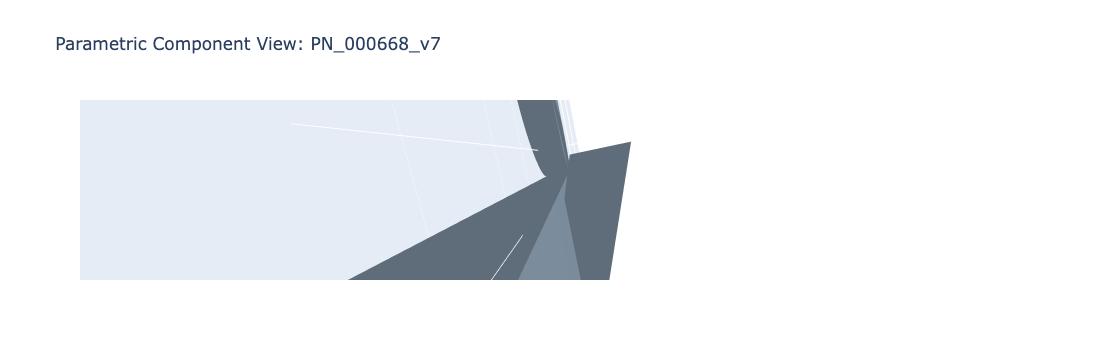

In [23]:
import os
from build123d import (
    BuildPart,
    BuildSketch,
    Circle,
    Locations,
    Mode,
    Plane,
    Polygon,
    Pos,
    Rectangle,
    add,
    export_step,
    export_stl,
    extrude,
)
import plotly.graph_objects as go


# -----------------------------------------------------------------------------
# Parameters (mm)
# Main T-shaped bracket kept unchanged.
# Bottom flange updated from PN_000668_v7_export.json:
#   d22 = 13 mm inclined length
#   d23 = 18 deg from vertical
#   d25 = 24 mm width
# -----------------------------------------------------------------------------
BASE_WIDTH = 60.0
BASE_HEIGHT = 15.0
BASE_CORNER_R = 5.0

TAB_WIDTH = 15.0
TAB_HEIGHT = 25.0
TAB_CORNER_R = 5.0
HOLE_DIA = 5.0
HOLE_Y = 24.6

THICKNESS = 1.6

RELIEF_WIDTH = 1.6
RELIEF_HEIGHT = 1.5
RELIEF_X = 12.6

# Updated bottom flange
# Exact Sketch2 profile from the Fusion export, converted to mm.
FLANGE_WIDTH = 24.0
FLANGE_PROFILE_POINTS = (
    (-0.8, -9.5),
    (0.8, -9.5),
    (4.740827725, -21.628620611),
    (3.293614129, -22.098848813),
)

OUT_NAME = "PN_000668_v7"


# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------
def rounded_rect_2d(width, height, radius, center=(0, 0), mode=Mode.ADD):
    cx, cy = center

    with Locations((cx, cy)):
        Rectangle(width - 2 * radius, height, mode=mode)
        Rectangle(width, height - 2 * radius, mode=mode)

    with Locations(
        (cx - width / 2 + radius, cy - height / 2 + radius),
        (cx + width / 2 - radius, cy - height / 2 + radius),
        (cx - width / 2 + radius, cy + height / 2 - radius),
        (cx + width / 2 - radius, cy + height / 2 - radius),
    ):
        Circle(radius, mode=mode)


def rounded_bottom_rect_2d(width, height, radius, center=(0, 0), mode=Mode.ADD):
    cx, cy = center

    with Locations((cx, cy + radius / 2)):
        Rectangle(width, height - radius, mode=mode)

    with Locations((cx, cy - height / 2 + radius / 2)):
        Rectangle(width - 2 * radius, radius, mode=mode)

    with Locations(
        (cx - width / 2 + radius, cy - height / 2 + radius),
        (cx + width / 2 - radius, cy - height / 2 + radius),
    ):
        Circle(radius, mode=mode)


# -----------------------------------------------------------------------------
# Main bracket (unchanged)
# -----------------------------------------------------------------------------
def build_main_plate():
    with BuildSketch(Plane.YZ) as sk:
        rounded_rect_2d(BASE_WIDTH, BASE_HEIGHT, BASE_CORNER_R, center=(0, -2.0))
        rounded_rect_2d(TAB_WIDTH, TAB_HEIGHT, TAB_CORNER_R, center=(0, 18.0))

        with Locations((0, HOLE_Y)):
            Circle(HOLE_DIA / 2, mode=Mode.SUBTRACT)

        with Locations(
            (-RELIEF_X, -8.75),
            (RELIEF_X, -8.75),
        ):
            Rectangle(RELIEF_WIDTH, RELIEF_HEIGHT, mode=Mode.SUBTRACT)

    return extrude(sk.sketch, amount=THICKNESS / 2, both=True)


# -----------------------------------------------------------------------------
# Updated bottom flange
# Rebuilt from the exact four-point Sketch2 profile used by Extrude2.
# -----------------------------------------------------------------------------
def build_flange():
    xs = [point[0] for point in FLANGE_PROFILE_POINTS]
    zs = [point[1] for point in FLANGE_PROFILE_POINTS]
    x_center = (min(xs) + max(xs)) / 2
    z_center = (min(zs) + max(zs)) / 2

    with BuildSketch(Plane.XZ) as sk:
        Polygon(*FLANGE_PROFILE_POINTS)

    flange = extrude(sk.sketch, amount=FLANGE_WIDTH / 2, both=True)
    return Pos(x_center, 0, z_center) * flange


# -----------------------------------------------------------------------------
# Build
# -----------------------------------------------------------------------------
def build_component():
    with BuildPart() as component:
        add(build_main_plate())
        add(build_flange())

    return component.part


# -----------------------------------------------------------------------------
# Export
# -----------------------------------------------------------------------------
def export_files(part, name=OUT_NAME):
    desktop = os.path.expanduser("~/Desktop")
    stl_path = os.path.join(desktop, f"{name}.stl")
    step_path = os.path.join(desktop, f"{name}.step")

    export_stl(part, stl_path)
    export_step(part, step_path)

    print(f"Successfully exported STL to: {stl_path}")
    print(f"Successfully exported STEP to: {step_path}")


# -----------------------------------------------------------------------------
# Plotly
# -----------------------------------------------------------------------------
def plot_component(part):
    vertices, triangles = part.tessellate(0.15)

    x = [v.X for v in vertices]
    y = [v.Y for v in vertices]
    z = [v.Z for v in vertices]

    i = [t[0] for t in triangles]
    j = [t[1] for t in triangles]
    k = [t[2] for t in triangles]

    fig = go.Figure(
        data=[
            go.Mesh3d(
                x=x,
                y=y,
                z=z,
                i=i,
                j=j,
                k=k,
                color="lightslategray",
                opacity=1.0,
                flatshading=True,
                name=OUT_NAME,
            )
        ]
    )

    fig.update_layout(
        scene=dict(
            xaxis=dict(title="X (mm)"),
            yaxis=dict(title="Y (mm)"),
            zaxis=dict(title="Z (mm)"),
            aspectmode="data",
        ),
        title=f"Parametric Component View: {OUT_NAME}",
    )

    return fig


if __name__ == "__main__":
    part = build_component()

    bb = part.bounding_box()
    print("Volume:", round(part.volume, 3), "mm^3")
    print("BBox min:", tuple(round(v, 3) for v in bb.min))
    print("BBox max:", tuple(round(v, 3) for v in bb.max))

    export_files(part)

    fig = plot_component(part)
    fig.show()
